# 22 · Weights in depth: the tiltrotor wing, the growth factor, and how honest the empty weight is

Tutorial 12 built the mass model from handbook correlations and XV-15 calibration factors. This notebook goes further into the three
weight topics that matter most when explaining the Halo's numbers to someone else:

1. **The tiltrotor wing**, which is sized by stiffness (whirl-flutter frequency placement) and a jump take-off, not by a GA strength regression;
   how that becomes smooth constraints in the sizing, and how well the model predicts two other tiltrotor wings without refitting.
2. **The growth factor as a multiplier**: on a mass closure, the dual of the closure equality *is* dMTOM/d(added mass).
3. **How honest the empty weight is**: the sizing's empty weight is a *basic* estimate; growth allowance and uncertainty are separate questions,
   answered by `examples/halo_oew_uncertainty.py`.

It runs on tutorial 19's near-reference design (from the cache).

**Run time:** about 10 seconds (or a minute if the cache is empty).

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from dataclasses import replace, fields
from examples.halo_sizing import HaloRequirements, HaloAssumptions, solve_halo_sizing, build_halo_aircraft
from aircraft_closure.vehicle.condition import StructuralDesignCondition
requirements = HaloRequirements()
reference = cached("reference_scholz", lambda: solve_halo_sizing(requirements, replace(HaloAssumptions(), aerodynamics_model="scholz")))
counts = {name: whole for name, (relaxed, whole) in reference.machine_units.items()}
assumptions = replace(HaloAssumptions(), aerodynamics_model="scholz", count_units_motor=counts["motor"],
                      count_units_generator=counts["generator"])
print(f"design: {lb(reference.mass_takeoff_kg):,.0f} lb take-off, {lb(reference.mass_empty_kg):,.0f} lb empty")

design: 15,134 lb take-off, 11,087 lb empty


## 1. The tiltrotor wing: sized by stiffness

A tiltrotor wing carries a heavy rotor and nacelle at each tip. It must keep its **torsion and beam frequencies above the rotor's once-per-rev** in
airplane mode, or the rotor-pylon-wing system can go into **whirl flutter**. It is then checked for strength in a **2 g jump take-off** (rotor thrust
at the tips). The AFDD method in NASA's NDARC (sec. 19-1.1, after Chappell and Peyran) sizes it in one explicit pass:

1. **torque box** from the torsion frequency: $GJ = \omega_T^2 I_\text{pylon}$ (a thin closed tube);
2. **spar caps** for the beam and chord frequencies where the box is not stiff enough;
3. extra caps for the **jump take-off** bending moment;
4. fairings, control surfaces and fittings by area or fraction.

The required frequencies are the XV-15's (torsion 1.09, beam 0.43, chord 0.83 per rev), **per rev of a design rotor speed that is itself a design
variable** (`HaloDesign.speed_rotor_wing_design_rad_s`). Every airplane-mode point of the mission then gets two margins: its own rotor speed must
keep the realized frequencies above the placement. That is the "reduced-order whirl flutter" constraint: smooth, no eigenvalue solve, no
iteration. `weights/afdd.py: wing_tiltrotor_afdd_masses` holds the equations; `vehicle/surfaces.py: TiltrotorWingMassModel` is the `Wing.mass_model`
slot that calls it.

In [2]:
from aircraft_closure.vehicle.surfaces import TiltrotorWingMassModel
print(inspect.getsource(TiltrotorWingMassModel).split('"""')[1])

AFDD tiltrotor wing mass submodel for `Wing.mass_model` (NDARC sec. 19-1.1; equations in `weights.afdd`).

    Span is the torque-box length (rotor centreline to centreline); chord is the mean chord. Frequencies are in
    per rev of `speed_rotor_design_rad_s`: the wing is built so that its torsion, beam and chord modes sit at those
    fractions of that rotor speed. Whirl-flutter placement at other rotor speeds is checked by the caller with
    `frequency_per_rev` (a margin, not a hidden loop). `mass_tip_kg` is the mass on one tip.

    Defaults are the XV-15 (plan 024): published modes at the 458 rpm airplane-mode rotor speed (Acree et al.
    stick model: symmetric torsion 8.3 Hz, beam 3.3 Hz, chord 6.3 Hz); torque-box chord ratio 0.45 (assumed); the
    torque-box efficiency, spar taper correction, fairing and control-surface unit masses and fittings fraction
    reproduce the published XV-15 wing breakdown (torque box 567, spars 52, control surfaces 97, fairings 108,
    fittings 

The sized wing's breakdown and the whirl-flutter placement at every airplane-mode point of the mission:

   mass_torque_box_kg           85.0 kg
   mass_spar_stiffness_kg       25.6 kg
   mass_spar_jump_kg            17.9 kg
   mass_fairing_kg              73.0 kg
   mass_control_surfaces_kg     65.3 kg
   mass_fittings_kg             39.5 kg
   mass_fold_kg                  0.0 kg
   total x 1.327 (XV-15 factor)  406.7 kg   (the sizing's wing: 406.7 kg)
PASS  the factored breakdown equals the sized wing


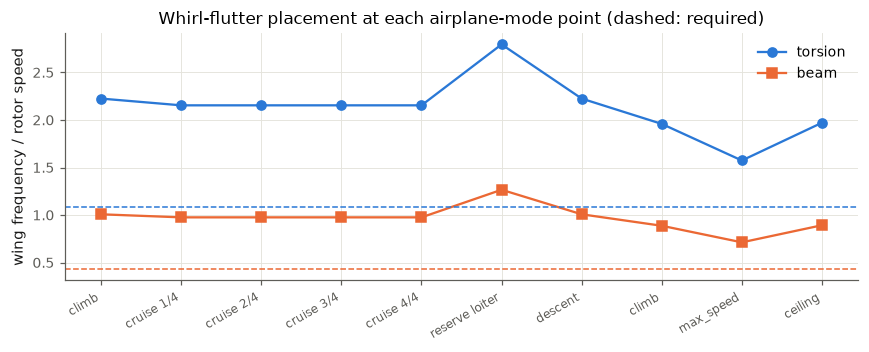

PASS  every airplane-mode point keeps its wing frequencies above the placement


In [3]:
from examples.xv15_reference import calibration_factors
factors = calibration_factors()
wing_masses = dict(reference.wing_masses_kg)
for name, kg in wing_masses.items():
    print(f"   {name:<26}{kg:7.1f} kg")
print(f"   {'total x ' + format(factors.wing_tiltrotor, '.3f') + ' (XV-15 factor)':<26}{sum(wing_masses.values()) * factors.wing_tiltrotor:7.1f} kg"
      f"   (the sizing's wing: {dict(reference.component_masses_kg)['wing']:.1f} kg)")
check("the factored breakdown equals the sized wing", abs(sum(wing_masses.values()) * factors.wing_tiltrotor - dict(reference.component_masses_kg)["wing"]) < 1e-6)

labels = [w["label"] for w in reference.whirl_flutter]
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.plot(range(len(labels)), [w["torsion_per_rev"] for w in reference.whirl_flutter], "o-", color=blue, label="torsion")
ax.plot(range(len(labels)), [w["beam_per_rev"] for w in reference.whirl_flutter], "s-", color=orange, label="beam")
ax.axhline(assumptions.frequency_torsion_wing_per_rev, color=blue, ls="--", lw=1)
ax.axhline(assumptions.frequency_beam_wing_per_rev, color=orange, ls="--", lw=1)
ax.set(xticks=range(len(labels)), ylabel="wing frequency / rotor speed", title="Whirl-flutter placement at each airplane-mode point (dashed: required)")
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8); ax.legend(); plt.tight_layout(); plt.show()
check("every airplane-mode point keeps its wing frequencies above the placement",
      all(w["torsion_per_rev"] >= assumptions.frequency_torsion_wing_per_rev - 1e-6 and w["beam_per_rev"] >= assumptions.frequency_beam_wing_per_rev - 1e-6
          for w in reference.whirl_flutter))

On this design the frequency margins are slack: the 1 mm minimum gauge of the torque box (added after a CalculiX check found 0.67 mm walls, plan 038)
already makes the box stiff enough, and the slow cruise rotor (advance-ratio bound, tutorial 08) helps.

**Competing effects of tip mass.** The model shows why moving the turbogenerators from the wing tips into the fuselage (plan 037) was not a simple win.
Less tip mass means less pylon inertia, so a lighter torque box, but also less inertia relief in the jump take-off, so heavier caps. Re-evaluate the
sized wing's model with the tip mass scaled:

In [4]:
aircraft = build_halo_aircraft(reference.design, requirements, assumptions)
wing = aircraft.wing
condition = StructuralDesignCondition(mass_design_kg=reference.mass_takeoff_kg, load_factor_ultimate=assumptions.load_factor_ultimate,
                                      velocity_cruise_m_s=reference.velocity_cruise_m_s, altitude_cruise_m=requirements.altitude_cruise_m,
                                      lift_to_drag_cruise=reference.lift_to_drag_cruise)
print(f"{'tip mass':>10}{'torque box':>12}{'stiffness caps':>16}{'jump caps':>11}{'total (raw)':>13}")
rows = []
for factor in (0.5, 0.75, 1.0, 1.5, 2.0):
    model = replace(wing.mass_model, mass_tip_kg=factor * wing.mass_model.mass_tip_kg)
    m = model.masses(wing, condition)
    rows.append((factor, scalar(m.mass_torque_box_kg), scalar(m.mass_spar_jump_kg)))
    print(f"{scalar(model.mass_tip_kg):9.0f} kg{scalar(m.mass_torque_box_kg):10.1f} kg{scalar(m.mass_spar_stiffness_kg):14.1f} kg"
          f"{scalar(m.mass_spar_jump_kg):9.1f} kg{scalar(m.total()):11.1f} kg")
check("more tip mass: heavier torque box but lighter jump caps (inertia relief)",
      rows[-1][1] > rows[0][1] and rows[-1][2] < rows[0][2])

  tip mass  torque box  stiffness caps  jump caps  total (raw)
      383 kg      84.8 kg           8.4 kg     53.4 kg      327.1 kg
      574 kg      84.8 kg          17.8 kg     34.6 kg      316.2 kg
      765 kg      85.0 kg          25.6 kg     17.9 kg      306.4 kg
     1148 kg     126.4 kg          30.0 kg      0.0 kg      338.3 kg
     1531 kg     168.5 kg          28.4 kg      0.0 kg      384.9 kg
PASS  more tip mass: heavier torque box but lighter jump caps (inertia relief)


(The torque box here may sit on its minimum gauge, which flattens its trend; the direction is still visible.)

### Validation without refitting

The model with its single XV-15 factor (`wing_tiltrotor` = 1.33) predicts two other tiltrotor wings (`examples/tiltrotor_wing_calibration.py`):

In [5]:
from examples.tiltrotor_wing_calibration import d266_wing_check, v22_wing_check
for result in (d266_wing_check(), v22_wing_check()):
    error = result.mass_predicted_calibrated_kg / result.mass_actual_kg - 1
    print(f"{result.aircraft:<10} predicted {lb(result.mass_predicted_calibrated_kg):6,.0f} lb, actual {lb(result.mass_actual_kg):6,.0f} lb, "
          f"error {error:+.0%}   ({result.note})")

Bell D266  predicted  1,840 lb, actual  1,886 lb, error -2%   (1968 preliminary-design statement; t/c and fuselage width assumed)
V-22 FSD   predicted  2,023 lb, actual  2,470 lb, error -18%   (wing without fold/rotate; tip mass from the framework model chain)


−2 % on the Bell D266 design and −18 % on the V-22 full-scale-development wing, whose tip mass is itself an estimate and whose fold/rotate scope is
unknown. A GA strength regression (Raymer) under-predicts the XV-15 wing by about half (tutorial 12's factor of 1.93), which is why the stiffness model
replaced it (plan 024).

## 2. The growth factor is the closure multiplier

For $\min m$ subject to $m - W(m) = 0$, adding a fixed mass $\Delta W$ shifts the constraint, and the multiplier of the closure equality says how much the
optimal $m$ moves: **|λ| = dMTOM/dΔW, the growth factor.** Check it on the calibrated XV-15 closure (fixed geometry: only the weight-dependent groups
grow):

In [6]:
from examples.xv15_reference import Xv15Reference, build_xv15_aircraft, design_condition

def xv15_closure(extra_kg):
    reference_xv15 = Xv15Reference()
    reference_xv15 = replace(reference_xv15, mass_useful_non_fuel_kg=reference_xv15.mass_useful_non_fuel_kg + extra_kg)
    xv15 = build_xv15_aircraft(reference_xv15, factors)
    opti = asb.Opti()
    m = opti.variable(init_guess=reference_xv15.mass_design_kg, scale=1000, lower_bound=1000)
    dual = opti.subject_to(m - xv15.get_mass_breakdown(design_condition(m, reference_xv15)).total().mass == 0)
    opti.minimize(m)
    solution = opti.solve(verbose=False)
    return solution.value(m), solution.value(dual)

m0, multiplier = xv15_closure(0.0)
m1, _ = xv15_closure(100.0)
print(f"finite difference: +100 kg -> +{m1 - m0:.1f} kg take-off, growth factor {(m1 - m0) / 100:.3f}")
print(f"closure multiplier: {multiplier:+.3f}")
check("|closure multiplier| equals the finite-difference growth factor", abs(abs(multiplier) - (m1 - m0) / 100) < 0.005)

finite difference: +100 kg -> +116.9 kg take-off, growth factor 1.169
closure multiplier: -1.170
PASS  |closure multiplier| equals the finite-difference growth factor


At fixed geometry the XV-15 grows about 1.2 kg per kg. In the Halo sizing, where wing, rotors, machines, battery and fuel all resize around fixed engines,
it is about 2.5 (tutorial 20). Every kilogram of empty-weight error is worth about 2.5 kg at take-off, which is why the next section matters.

## 3. How honest is the empty weight?

The sizing's empty weight is a **basic** estimate: no growth allowance, no margin. `examples/halo_oew_uncertainty.py` lists the empty weight as items, and
gives each item two separate quantities:

- **growth allowance**, by design maturity (AIAA S-120A / SAWE mass-growth practice): vendor hardware 2 %, vendor data 5 %, calculated or layout 8 %,
  calibrated parametric 10 %, estimated 15 %. Allowances add: predicted OEW = basic + Σ allowances;
- **uncertainty (1σ)** from how the item is estimated. Items are treated as independent, so σ_OEW is the root sum of squares.

They answer different questions: *what will it weigh when the design matures?* and *how sure are we?*

In [7]:
from examples.halo_oew_uncertainty import oew_distribution, oew_items, probability_at_most
items = oew_items(reference)
print(f"{'item':<28}{'kg':>8}  {'maturity':<24}{'sigma':>6}  basis")
for item in items:
    print(f"{item.label:<28}{item.mass_kg:8.1f}  {item.maturity:<24}{item.sigma_fraction:6.0%}  {item.basis[:60]}")
dist = oew_distribution(items)
check("the items add up to the sizing's empty weight", abs(dist.basic_lb - lb(reference.mass_empty_kg)) < 1.0)

item                              kg  maturity                 sigma  basis
Wing                           406.7  Calibrated parametric      10%  AFDD tiltrotor wing x 1.33 (XV-15); strength at ultimate not
Tails                           81.9  Calibrated parametric      10%  Raymer x XV-15 factor
Fuselage                       552.0  Calculated / layout        10%  Raymer x 1.70, anchored to the drawn layout
Nacelles                       194.8  Calibrated parametric      10%  AFDD-class estimate
Landing gear                   257.8  Calibrated parametric       8%  Raymer x XV-15 factor
Systems                        406.1  Calibrated parametric      15%  Raymer; flight controls carry an XV-15 factor of about 4
Fixed equipment                266.3  Estimated                  10%  Assumed allowance
Rotors                         672.3  Calibrated parametric       8%  AFDD blades and hubs, XV-15 calibrated
Rotor gearboxes                291.4  Calibrated parametric      10%  AFDD drive 

basic OEW 11,087 lb + growth 958 lb (8.6%) = predicted 12,045 lb; sigma 278 lb; 99 % value 12,693 lb
chance of meeting a not-to-exceed target set at today's basic OEW: 2.9e-04


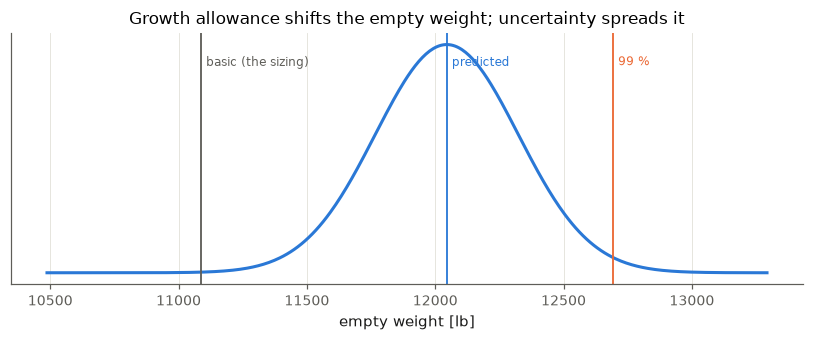

PASS  the growth allowance exceeds three standard deviations


In [8]:
print(f"basic OEW {dist.basic_lb:,.0f} lb + growth {dist.growth_lb:,.0f} lb ({dist.growth_lb / dist.basic_lb:.1%}) = predicted {dist.mean_lb:,.0f} lb; "
      f"sigma {dist.sigma_lb:,.0f} lb; 99 % value {dist.value_99_lb:,.0f} lb")
print(f"chance of meeting a not-to-exceed target set at today's basic OEW: {probability_at_most(dist, dist.basic_lb):.1e}")
x = onp.linspace(dist.basic_lb - 600, dist.value_99_lb + 600, 400)
density = onp.exp(-0.5 * ((x - dist.mean_lb) / dist.sigma_lb)**2)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(x, density, color=blue, lw=2)
for value, label, color in ((dist.basic_lb, "basic (the sizing)", ink_muted), (dist.mean_lb, "predicted", blue), (dist.value_99_lb, "99 %", orange)):
    ax.axvline(value, color=color, lw=1.2); ax.text(value + 20, 0.95, label, color=color, fontsize=8, va="top")
ax.set(xlabel="empty weight [lb]", yticks=[], title="Growth allowance shifts the empty weight; uncertainty spreads it")
plt.tight_layout(); plt.show()
check("the growth allowance exceeds three standard deviations", dist.growth_lb > 3 * dist.sigma_lb)

The growth allowance (about 960 lb) is more than three standard deviations (about 280 lb). Sizing to the basic weight means essentially no chance of
meeting a not-to-exceed target set at that weight; the 99 % value is about 1,600 lb over. And σ is probably optimistic: the items are not independent
(every group calibrated on the same aircraft can be biased the same way), and the spread is at fixed take-off weight, before the growth factor of about 2.5.

## Limits and next steps

**What the weights model can't do**

- **Wing strength at ultimate load is not demonstrated.** A linear CalculiX check (plans 031, 038) puts the peak spar-cap strain 10 % above the ultimate
  allowable in the jump take-off, with the raw AFDD gauges and an idealized root clamp (whether the 1.33 calibration material is load-carrying is open).
  No buckling analysis yet; plate estimates suggest the 1 mm covers need stiffening.
- **Whirl flutter is a frequency margin, not a stability analysis**: no rotor-pylon-wing eigenvalues, no damping.
- **Weights calibrate on one aircraft**, with some factors (flight controls ≈ 3.8, rotor ≈ 0.7) that stand in for missing physics.
- **Structural loads use cruise dynamic pressure, not a dive speed**: Raymer's fuselage mass grows with cruise q, so a faster cruise makes the fuselage
  heavier.
- **No weight margin in the sizing**: the reference is sized to the basic estimate.

**What's next** (README work packages)

- **Weights:** run weight control from the item table, allocate a not-to-exceed weight per item, and carry each item's growth allowance and uncertainty
  inside the sizing, so the aircraft is sized to its 99 % value.
- **Stress and aeroelasticity:** start from the exported Nastran decks; real fittings and stiffened covers; strength and buckling (SOL 101, 105) to a margin
  ≥ 0 at ultimate; return calibrated wing weights to the sizing. Then Nastran flutter (SOL 145) and whirl flutter with rotor aerodynamics, replacing the
  frequency margins.
- A coupled rotor-pylon-wing whirl model in CasADi (`docs/NEXT_STEPS.md`): a small eigenproblem with the critical eigenpair as variables and a damping
  margin.

## Summary

- The tiltrotor wing is sized by torsion and beam frequencies per rev of a design rotor speed (a variable) and by a jump take-off; whirl flutter becomes
  smooth per-point margins. Validated at −2 % (D266) and −18 % (V-22) without refitting.
- The closure multiplier is the growth factor (about 1.2 for the XV-15 at fixed geometry, about 2.5 for the resizing Halo).
- The sizing's empty weight is basic. Growth allowance (about 960 lb) and uncertainty (σ about 280 lb) are separate, and the allowance dominates.

## Check yourself

<details><summary>1. Why make the wing's design rotor speed a variable instead of using the hover rotor speed?</summary>

The frequencies only need to clear the rotor speeds the wing actually sees in airplane mode, which are lower than hover (the advance-ratio bound slows the cruise rotor). A variable design speed, with a margin at every airplane-mode point, lets the optimizer trade wing stiffness against cruise rotor speed without any hidden loop.
</details>

<details><summary>2. A reviewer asks "what does the Halo weigh?" What is the honest answer?</summary>

The basic estimate (the sizing), plus a growth allowance by item maturity (about 960 lb), with a 1σ uncertainty of about 280 lb that is probably optimistic. A not-to-exceed target should be set near the 99 % value, and every pound of it costs about 2.5 at take-off.
</details>

In [9]:
check_summary()

6 of 6 checks passed
